# Test random-intercepts

## Load data


### Adapted notebook from Peter. June 2026. Added INLA / DALIA comparison.

In [1]:
# setup DALIA paths
library(here)
folder_path <- here()
print(folder_path)

result_folder_dalia = paste0(folder_path, "/../../../dalia-project/DALIA/examples/g_federated")
print(result_folder_dalia)

here() starts at /Users/lisa/Library/Mobile Documents/com~apple~CloudDocs/uni/repositories/federated_learning/confeR



[1] "/Users/lisa/Library/Mobile Documents/com~apple~CloudDocs/uni/repositories/federated_learning/confeR"
[1] "/Users/lisa/Library/Mobile Documents/com~apple~CloudDocs/uni/repositories/federated_learning/confeR/../../../dalia-project/DALIA/examples/g_federated"


In [2]:
library(confeR)
library(lme4)
library(dplyr)
library(ggplot2)
set.seed(123)

# Load nurses data (Gaussian)
data(nurses_hom, package = "confeR")
df_raw <- nurses_hom$data_ipd

subsample_hospital <- function(df, id, N) {
  site_rows <- df[df$hospital == id, ]
  if (nrow(site_rows) >= N) {
    sampled_site <- site_rows[sample(nrow(site_rows), N, replace = FALSE), ]
  } else {
    sampled_site <- site_rows
  }

  other_sites <- df[df$hospital != id, ]
  rbind(sampled_site, other_sites)
}

# We can subsample some of the hospitals to simulate low sample size scenario
# Low-powered sites should have overfitted fixed-effects, hence stronger shrinkage from random intercepts
df <- subsample_hospital(df_raw, id = 1, N = 5)
df <- subsample_hospital(df, id = 2, N = 3)
df <- subsample_hospital(df, id = 4, N = 9)

# We can reduce the number of hospitals if needed
# df <- df[as.integer(df$hospital) < 10, ]

# Print sample suze for each hospital
table(df$hospital)


Loading required package: Matrix


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union





 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 
 5  3 39  9 38 37 45 32 47 41 48 38 27 35 50 29 37 42 48 38 46 45 45 40 40 

## Fit models


In [3]:
# Random intercepts model
formula <- stress ~ 0 + age + (1 | hospital)
res_re <- lmer(formula, data = df)

# Fixed intercepts model
formula <- stress ~ 0 + age + hospital
res_fe <- lm(formula, data = df)

# We can also add additional covariates in the model, for now we keep it simple
# age + gender + experience + wardtype


In [4]:
fe <- coef(res_fe)
fe_df <- data.frame(
  hospital = as.integer(sub("^hospital", "", names(fe)[grepl("^hospital", names(fe))])),
  fe = fe[grepl("^hospital", names(fe))]
)
print(fe_df)

re <- ranef(res_re)$hospital
re_df <- data.frame(
  hospital = rownames(re),
  re = re[, "(Intercept)"]
)
print(re_df)

           hospital          fe
hospital1         1 -0.32266823
hospital2         2  0.62722147
hospital3         3  0.08737296
hospital4         4 -0.59509759
hospital5         5  0.19172017
hospital6         6  0.11080196
hospital7         7  0.11541166
hospital8         8  0.37859637
hospital9         9  0.17526148
hospital10       10  0.19006500
hospital11       11  0.14709441
hospital12       12  0.05257602
hospital13       13  0.05881223
hospital14       14  0.24242822
hospital15       15  0.32057721
hospital16       16  0.16254794
hospital17       17 -0.07937694
hospital18       18  0.28883301
hospital19       19  0.23412859
hospital20       20  0.06301598
hospital21       21  0.31917950
hospital22       22  0.02158700
hospital23       23 -0.01753439
hospital24       24  1.24861525
hospital25       25 -0.24484151
   hospital          re
1         1 -0.07708958
2         2  0.09929351
3         3  0.06201120
4         4 -0.21481763
5         5  0.13480286
6         6  0.07740399


In [5]:
# R-INLA fits: fixed effects and random intercepts
if (!requireNamespace("INLA", quietly = TRUE)) {
  stop("INLA package not available")
}

# Keep priors consistent across both models
inla_prior_lambda <- 0.001

# Fixed-effects model in INLA (hospital as fixed effect)
formula_inla_fe <- stress ~ 0 + age + hospital
res_inla_fe <- INLA::inla(
  formula = formula_inla_fe,
  family = "gaussian",
  data = df,
  control.fixed = list(
    mean = 0,
    prec = inla_prior_lambda,
    mean.intercept = 0,
    prec.intercept = inla_prior_lambda
  ),
  control.compute = list(dic = TRUE, waic = TRUE)
 )

# Random-intercepts model in INLA (hospital as iid random effect)
formula_inla_re <- stress ~ 0 + age + f(
  hospital,
  model = "iid",
  hyper = list(prec = list(prior = "loggamma", param = c(1.0, 0.1)))
)
res_inla_re <- INLA::inla(
  formula = formula_inla_re,
  family = "gaussian",
  data = df,
  control.fixed = list(
    mean = 0,
    prec = inla_prior_lambda,
    mean.intercept = 0,
    prec.intercept = inla_prior_lambda
  ),
  control.compute = list(dic = TRUE, waic = TRUE)
 )

# Optional quick check
res_inla_fe$dic$dic
res_inla_re$dic$dic

[1] 2784.837

[1] 2776.452

In [6]:
# load dalia results 
## read in DALIA results on random effects
output_file_dalia <- file.path(result_folder_dalia, "dalia_summary_nurses_hom_site_specific_intercept.csv")

dalia_results <- read.csv(output_file_dalia)
dalia_re = dalia_results$Estimate[2:(length(dalia_results$Estimate)-2)]
head(dalia_re)

[1] -0.08847765  0.11580199  0.06521702 -0.24085539  0.14197024  0.08157035

In [7]:
# need to further investigate effect of hyperparameter prior
cbind(lmer_re=re_df$re, inla_re=res_inla_re$summary.random$hospital$mean, dalia_re=dalia_re,lm_fe=fe_df$fe, inla_fe=res_inla_fe$summary.fixed[grepl("hospital", rownames(res_inla_fe$summary.fixed)), "mean"])

lmer_re,inla_re,dalia_re,lm_fe,inla_fe
-0.07708958,-0.08174927,-0.08847765,-0.32266823,-0.32258835
0.09929351,0.10696229,0.11580199,0.62722147,0.62696335
0.06201120,0.06234796,0.06521702,0.08737296,0.08737020
-0.21481763,-0.22340347,-0.24085539,-0.59509759,-0.59501572
0.13480286,0.13558601,0.14197024,0.19172017,0.19171415
0.07740399,0.07787321,0.08157035,0.11080196,0.11079828
0.08527600,0.08561042,0.08921271,0.11541166,0.11540844
0.25277927,0.25478898,0.26783673,0.37859637,0.37858167
0.13081669,0.13128367,0.13669123,0.17526148,0.17525691
0.13701230,0.13767312,0.14378667,0.19006500,0.19005913


## Shrinkage


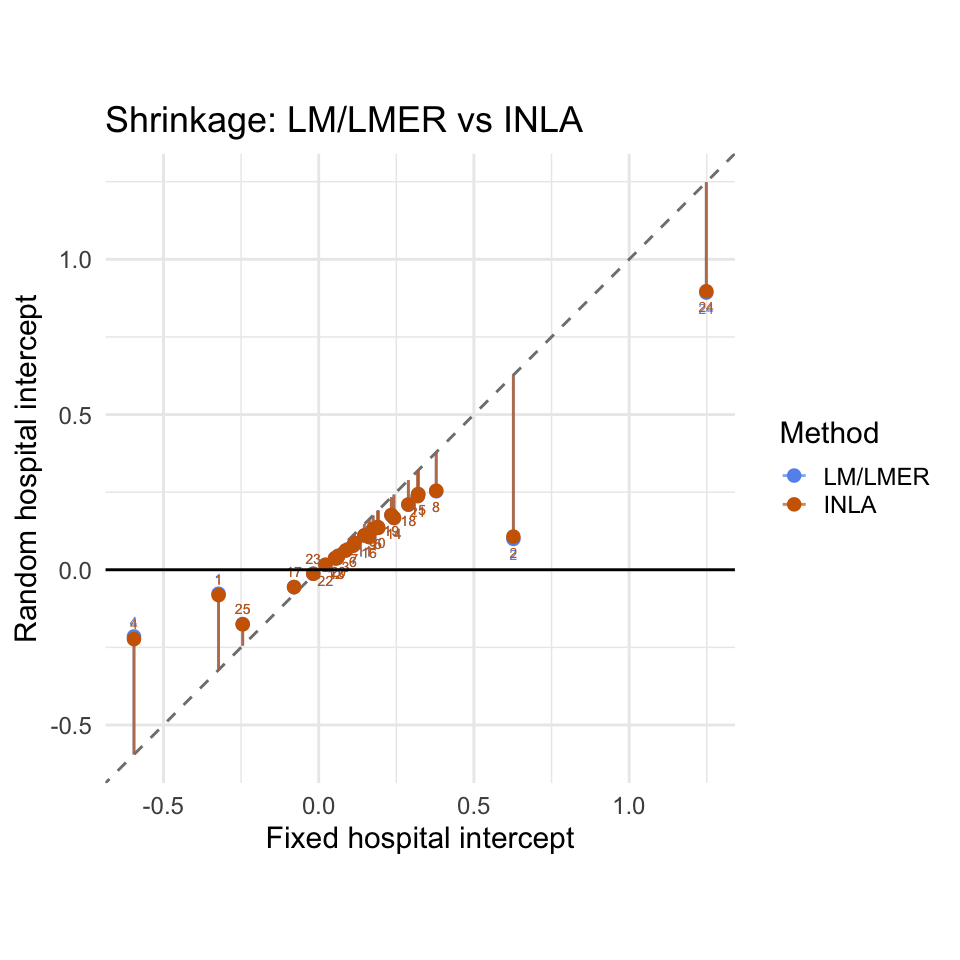

In [8]:
plot_df <- merge(fe_df, re_df, by = "hospital")
plot_df$Method <- "LM/LMER"

# Build matching INLA fixed/random hospital effects
inla_fe <- res_inla_fe$summary.fixed
inla_fe_df <- data.frame(
  hospital = rownames(inla_fe)[grepl("^hospital", rownames(inla_fe))],
  fe = inla_fe[grepl("^hospital", rownames(inla_fe)), "mean"],
  stringsAsFactors = FALSE
)
inla_fe_df$hospital <- sub("^hospital", "", inla_fe_df$hospital)

inla_re_df <- data.frame(
  hospital = as.character(res_inla_re$summary.random$hospital$ID),
  re = res_inla_re$summary.random$hospital$mean,
  stringsAsFactors = FALSE
)

plot_inla_df <- merge(inla_fe_df, inla_re_df, by = "hospital")
plot_inla_df$Method <- "INLA"

# Combine and use slight y-offset for labels
plot_all_df <- rbind(plot_df, plot_inla_df)
plot_all_df$y_label <- plot_all_df$re - 0.05 * sign(plot_all_df$re)
plot_all_df$Method <- factor(plot_all_df$Method, levels = c("LM/LMER", "INLA"))

options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(plot_all_df, aes(x = fe, y = re, color = Method)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  geom_segment(aes(xend = fe, yend = fe), alpha = 0.7) +
  geom_point(size = 3) +
  geom_text(aes(label = hospital, y = y_label), size = 3, show.legend = FALSE) +
  scale_color_manual(values = c("LM/LMER" = "cornflowerblue", "INLA" = "darkorange3")) +
  labs(
    x = "Fixed hospital intercept",
    y = "Random hospital intercept",
    title = "Shrinkage: LM/LMER vs INLA"
  ) +
  geom_hline(yintercept = 0) +
  coord_equal() +
  theme_minimal(base_size = 18)

We see that sites 1, 2, and 4 with the small sample sizes are shrunk strongly. Note also that sites 24 and 25 were originally constructed as outlier sites in the data.


In [9]:
# Print the hospital intercepts
# Column "re" is what we want to recover in federated estimate with DALIA
plot_df |> dplyr::select(c("hospital", "fe", "re"))


hospital,fe,re
<int>,<dbl>,<dbl>
1,-0.32266823,-0.07708958
2,0.62722147,0.09929351
3,0.08737296,0.06201120
4,-0.59509759,-0.21481763
5,0.19172017,0.13480286
6,0.11080196,0.07740399
7,0.11541166,0.08527600
8,0.37859637,0.25277927
9,0.17526148,0.13081669


## Predictions

Let's make predictions using the patients we previously dropped during subsampling


In [10]:
# Data with previously dropped patients
df_diff <- df_raw[!(row.names(df_raw) %in% row.names(df)), ]
df_diff$pred_fe <- predict(res_fe, newdata = df_diff)
df_diff$pred_re <- predict(res_re, newdata = df_diff) # allow.new.levels = TRUE)

print(dim(df_diff))
head(df_diff, 20)


[1] 96  8


,gender,age,experience,wardtype,stress,hospital,pred_fe,pred_re
,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<fct>,<dbl>,<dbl>
1,0,0.87196495,0.44631302,1,-0.13530432,1,-0.068390799,0.17781588
3,0,0.51850377,0.44246477,0,-0.71324414,1,-0.171465128,0.07448697
10,0,1.12500275,-1.18748608,0,2.46636859,2,0.955288336,0.42817065
15,0,-0.21404124,0.78767673,1,-0.28600051,4,-0.657515075,-0.27738927
37,1,0.18184719,0.50848479,1,-0.83040110,4,-0.542068356,-0.16165742
50,1,-0.07921171,-0.27962991,1,0.15923434,2,0.604122210,0.07613720
97,1,-0.05129789,1.10256520,0,-1.02250261,1,-0.337627424,-0.09208572
115,1,-0.44478198,-1.09330076,0,-0.48608243,1,-0.452373003,-0.20711470
118,1,0.07216675,1.01875797,0,-0.13853438,2,0.648266330,0.12039035


In [11]:
# Save df_raw to CSV with a simple fit indicator (1 = in initial fit, NA = prediction set)
outpath <- normalizePath("../../paper/data/summarized", winslash = "/", mustWork = FALSE)
if (!dir.exists(outpath)) dir.create(outpath, recursive = TRUE)

df_raw_export <- df_raw
df_raw_export$in_initial_fit <- as.integer(row.names(df_raw_export) %in% row.names(df))
df_raw_export$in_initial_fit[df_raw_export$in_initial_fit == 0] <- NA_integer_

dataname_export <- "nurses_hom"
family_export <- "gaussian"
file_name <- file.path(outpath, paste0("data_", dataname_export, "_", family_export, "_with_fit_indicator.csv"))

write.csv(df_raw_export, file_name, row.names = FALSE)
cat("Saved CSV to:", file_name, "\n")
table(is.na(df_raw_export$in_initial_fit))

Saved CSV to: /Users/lisa/Library/Mobile Documents/com~apple~CloudDocs/uni/repositories/federated_learning/confeR/paper/data/summarized/data_nurses_hom_gaussian_with_fit_indicator.csv 



FALSE  TRUE 
  904    96 

In [12]:
df_diff$err_fe <- df_diff$stress - df_diff$pred_fe
df_diff$err_re <- df_diff$stress - df_diff$pred_re

rmse <- function(e) sqrt(mean(e^2, na.rm = TRUE))
cat("Fixed-effect RMSE:", rmse(df_diff$err_fe), "\n")
cat("Random-effect RMSE:", rmse(df_diff$err_re), "\n")



Fixed-effect RMSE: 1.050281 
Random-effect RMSE: 0.978618 


In [13]:
# sort df by hospital id for better visualization
df <- df[order(df$hospital), ]

## make predictions with INLA models
df_INLA <- df_raw
df_INLA$observed_stress <- df_INLA$stress
# here we refit the model but with the df_diff outcome marked as NA
df_INLA$stress <- ifelse(row.names(df_INLA) %in% row.names(df_diff), NA, df_INLA$stress)
df_INLA <- df_INLA[order(df_INLA$hospital), ]
head(df_INLA, 10)

,gender,age,experience,wardtype,stress,hospital,observed_stress
,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<fct>,<dbl>
1,0,0.87196495,0.44631302,1,NA,1,-0.13530432
3,0,0.51850377,0.44246477,0,NA,1,-0.71324414
57,0,-0.13180279,-2.16841775,1,1.017022,1,1.01702223
97,1,-0.05129789,1.10256520,0,NA,1,-1.02250261
115,1,-0.44478198,-1.09330076,0,NA,1,-0.48608243
133,1,0.84053983,0.76130990,1,NA,1,-1.38877994
153,0,1.68758948,-0.01375342,1,NA,1,0.33915316
155,0,1.07494508,0.41430816,1,NA,1,-1.33332677
166,1,0.94116581,1.57785198,0,NA,1,-0.98964642


In [14]:
# Keep priors consistent across both models
inla_prior_lambda <- 0.001

# Fixed-effects model in INLA (hospital as fixed effect)
formula_inla_fe <- stress ~ 0 + age + hospital
res_inla_fe_pred <- INLA::inla(
  formula = formula_inla_fe,
  family = "gaussian",
  data = df_INLA,
  control.fixed = list(
    mean = 0,
    prec = inla_prior_lambda,
    mean.intercept = 0,
    prec.intercept = inla_prior_lambda
  ),
  control.compute = list(dic = TRUE, waic = TRUE),
  control.inla=list(int.strategy='eb')
 )

# Random-intercepts model in INLA (hospital as iid random effect)
formula_inla_re <- stress ~ 0 + age + f(
  hospital,
  model = "iid",
  hyper = list(prec = list(prior = "loggamma", param = c(1.0, 0.1)))
)
res_inla_re_pred <- INLA::inla(
  formula = formula_inla_re,
  family = "gaussian",
  data = df_INLA,
  control.fixed = list(
    mean = 0,
    prec = inla_prior_lambda,
    mean.intercept = 0,
    prec.intercept = inla_prior_lambda
  ),
  control.compute = list(dic = TRUE, waic = TRUE)#,
  #control.inla=list(int.strategy='eb')
 )

# Optional quick check
res_inla_fe$dic$dic
res_inla_re$dic$dic


[1] 2784.837

[1] 2776.452

In [15]:
# Extract predictions only for rows masked as NA during INLA fit
idx_missing <- which(is.na(df_INLA$stress))

pred_compare <- data.frame(
  row_id = idx_missing,
  hospital = df_INLA$hospital[idx_missing],
  observed_stress = df_INLA$observed_stress[idx_missing],
  pred_INLA_fe = res_inla_fe_pred$summary.fitted.values[idx_missing, "mean"],
  pred_INLA_re = res_inla_re_pred$summary.fitted.values[idx_missing, "mean"]
 )
pred_compare <- pred_compare[order(pred_compare$hospital), ]

pred_compare$err_INLA_fe <- pred_compare$observed_stress - pred_compare$pred_INLA_fe
pred_compare$err_INLA_re <- pred_compare$observed_stress - pred_compare$pred_INLA_re

rmse <- function(e) sqrt(mean(e^2, na.rm = TRUE))
cat("INLA fixed-effect RMSE (masked rows):", rmse(pred_compare$err_INLA_fe), "\n")
cat("INLA random-effect RMSE (masked rows):", rmse(pred_compare$err_INLA_re), "\n")

print(dim(pred_compare))
head(pred_compare,20)


INLA fixed-effect RMSE (masked rows): 1.050231 
INLA random-effect RMSE (masked rows): 0.9787349 
[1] 96  7


,row_id,hospital,observed_stress,pred_INLA_fe,pred_INLA_re,err_INLA_fe,err_INLA_re
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1,-0.13530432,-0.068311428,0.17340833,-0.066992889,-0.30871264
2,2,1,-0.71324414,-0.171385603,0.07007832,-0.541858537,-0.78332246
3,4,1,-1.02250261,-0.337547651,-0.09649584,-0.684954954,-0.92600676
4,5,1,-0.48608243,-0.452293059,-0.21152563,-0.033789371,-0.27455680
5,6,1,-1.38877994,-0.077475430,0.16422157,-1.311304514,-1.55300152
6,7,1,0.33915316,0.169535973,0.41184665,0.169617191,-0.07269349
7,8,1,-1.33332677,-0.009119615,0.23274712,-1.324207153,-1.56607389
8,9,1,-0.98964642,-0.048131502,0.19363836,-0.941514915,-1.18328477
9,10,1,-0.03047101,-0.025068578,0.21675855,-0.005402430,-0.24722956


In addition to shrinkage, another advantage of random effects is that we can also make predictions for previously unseen hospitals.


In [16]:
## read in DALIA results on random effects
result_folder_dalia <- "/Users/lisa/Library/Mobile Documents/com~apple~CloudDocs/uni/dalia-project/DALIA/examples/g_federated"
output_file_dalia <- file.path(result_folder_dalia, "dalia_predictions_nurses_hom_site_specific_intercept.csv")

dalia_results <- read.csv(output_file_dalia)
print(dim(dalia_results))

# Insert DALIA predictions and place directly after pred_INLA_re
pred_compare$dalia_pred_re <- dalia_results$mean_predict
pred_compare <- pred_compare |>
  dplyr::relocate(dalia_pred_re, .after = pred_INLA_re)

pred_compare$err_dalia_re <- pred_compare$observed_stress - pred_compare$dalia_pred_re

cat("DALIA random-effect RMSE (masked rows):", rmse(pred_compare$err_dalia), "\n")

head(pred_compare, 10)


[1] 96  2
DALIA random-effect RMSE (masked rows): 0.9795106 


,row_id,hospital,observed_stress,pred_INLA_fe,pred_INLA_re,dalia_pred_re,err_INLA_fe,err_INLA_re,err_dalia_re
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1,-0.13530432,-0.068311428,0.17340833,0.16626943,-0.06699289,-0.30871264,-0.30157375
2,2,1,-0.71324414,-0.171385603,0.07007832,0.06300472,-0.54185854,-0.78332246,-0.77624886
3,4,1,-1.02250261,-0.337547651,-0.09649584,-0.10346447,-0.68495495,-0.92600676,-0.91903814
4,5,1,-0.48608243,-0.452293059,-0.21152563,-0.21842198,-0.03378937,-0.27455680,-0.26766045
5,6,1,-1.38877994,-0.077475430,0.16422157,0.15708849,-1.31130451,-1.55300152,-1.54586843
6,7,1,0.33915316,0.169535973,0.41184665,0.40455648,0.16961719,-0.07269349,-0.06540332
7,8,1,-1.33332677,-0.009119615,0.23274712,0.22557066,-1.32420715,-1.56607389,-1.55889742
8,9,1,-0.98964642,-0.048131502,0.19363836,0.18648666,-0.94151491,-1.18328477,-1.17613307
9,10,1,-0.03047101,-0.025068578,0.21675855,0.20959221,-0.00540243,-0.24722956,-0.24006322
